# FMCG Sales & Supply Chain Analysis (2022–2024)

This project analyzes FMCG sales data to explore:

- revenue distribution across regions and sales channels
- promotion impact on sales
- sales trends and seasonal patterns
- inventory turnover and stock shortages
- supply chain and delivery performance

The dataset simulates FMCG business operations across different:

- regions
- sales channels
- product categories
- inventory conditions

# Business Questions

1. Which regions and sales channels generate the highest revenue?
2. Do promotions significantly increase sales?
3. Are there visible sales trends during different periods of the year?
4. How does inventory turnover differ across product categories?
5. Are stock shortages more related to delivery delays or product demand?

### Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("FMCG_2022_2024.csv")

df.head()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,22/01/21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,22/01/22,MI-006,MiBrand1,Milk-Seg3,Milk,E-commerce,PL-Central,Carton,5.34,0,1,160,140,11
2,22/01/22,MI-026,MiBrand4,Milk-Seg2,Milk,Retail,PL-North,Carton,7.96,0,1,88,106,9
3,22/01/22,MI-026,MiBrand4,Milk-Seg2,Milk,Discount,PL-North,Multipack,8.56,0,1,161,172,11
4,22/01/22,MI-026,MiBrand4,Milk-Seg2,Milk,Discount,PL-North,Multipack,8.56,0,1,161,172,11


In [4]:
display(df.shape)
df.info()
display(df.describe())

(190760, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190760 entries, 0 to 190759
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             190760 non-null  object 
 1   sku              190760 non-null  object 
 2   brand            190760 non-null  object 
 3   segment          190760 non-null  object 
 4   category         190760 non-null  object 
 5   channel          190760 non-null  object 
 6   region           190760 non-null  object 
 7   pack_type        190758 non-null  object 
 8   price_unit       190760 non-null  float64
 9   promotion_flag   190760 non-null  int64  
 10  delivery_days    190760 non-null  int64  
 11  stock_available  190760 non-null  int64  
 12  delivered_qty    190760 non-null  int64  
 13  units_sold       190760 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 20.4+ MB


,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
count,190760.000000,190760.000000,190760.000000,190760.000000,190760.000000,190760.00000
mean,5.251969,0.149198,3.004839,157.697646,179.333293,19.91959
std,2.166718,0.356284,1.414644,52.735755,40.037300,11.77003
min,1.500000,0.000000,0.000000,-12.000000,-11.000000,-25.00000
25%,3.370000,0.000000,2.000000,124.000000,152.000000,12.00000
50%,5.250000,0.000000,3.000000,155.000000,179.000000,18.00000
75%,7.130000,0.000000,4.000000,192.000000,206.000000,25.00000
max,9.000000,1.000000,5.000000,405.000000,366.000000,139.00000


In [9]:
display(df.duplicated().sum())
display(df.isna().sum())

np.int64(3)

date               0
sku                0
brand              0
segment            0
category           0
channel            0
region             0
pack_type          2
price_unit         0
promotion_flag     0
delivery_days      0
stock_available    0
delivered_qty      0
units_sold         0
dtype: int64

**Data Quality Issues:**
- incorrect data type in the date column
- negative values in stock and sales columns
- suspicious delivery_days values
- missing values in pack_type

### Data Cleaning

In [10]:
#remove duplicates
df_clean = df.drop_duplicates()

In [11]:
#negative value filtering
df_clean = df_clean.loc[(df_clean["stock_available"] >= 0) & 
    (df_clean["delivered_qty"] >= 0) & 
    (df_clean["units_sold"] >= 0)]

In [12]:
#missing value handling
df_clean["pack_type"] = (df_clean["pack_type"].fillna(df_clean["pack_type"].mode()[0]))

In [13]:
#delivery days validation
df_clean = df_clean.loc[df_clean["delivery_days"] >= 1]

In [14]:
#date conversion
df_clean["date"] = pd.to_datetime(df_clean["date"], format="%y/%m/%d")

### Feature Engineering

New analytical features were created for revenue, seasonality, and inventory analysis

In [16]:
#revenue metric
df_clean["revenue"] = (df_clean["units_sold"] *df_clean["price_unit"])

#calendar features
df_clean["year"] = df_clean["date"].dt.year
df_clean["month"] = df_clean["date"].dt.month
df_clean["weekday"] = df_clean["date"].dt.day_name()

#inventory turnover metric
turnover_df = df_clean.loc[df_clean["stock_available"] > 0].copy()

turnover_df["stock_turnover"] = (turnover_df["units_sold"] / turnover_df["stock_available"])

### Revenue Analysis

This section analyzes revenue distribution across regions and sales channels

**Revenue by region**

In [34]:
revenue_by_region = (df_clean.groupby('region')['revenue'].sum().sort_values(ascending=False))

display(revenue_by_region)

top_region = revenue_by_region.index[0]
share_top_region = revenue_by_region.iloc[0] / revenue_by_region.sum() * 100

region
PL-South      6666238.54
PL-North      6664220.52
PL-Central    6620776.29
Name: revenue, dtype: float64

**Revenue by channel**

In [33]:
revenue_by_channel = (df_clean.groupby('channel')['revenue'].sum().sort_values(ascending=False))

display(revenue_by_channel)

top_channel = revenue_by_channel.index[0]
top_channel_share = revenue_by_channel.iloc[0] / revenue_by_channel.sum() * 100

channel
Retail        6655499.06
E-commerce    6653435.41
Discount      6642300.88
Name: revenue, dtype: float64

In [36]:
region_summary = pd.DataFrame({"Revenue": revenue_by_region, "Revenue Share (%)": (revenue_by_region / revenue_by_region.sum()) * 100})
channel_summary = pd.DataFrame({"Revenue": revenue_by_channel, "Revenue Share (%)": (revenue_by_channel / revenue_by_channel.sum()) * 100})

display(region_summary)
display(channel_summary)

,Revenue,Revenue Share (%)
region,,
PL-South,6666238.54,33.412661
PL-North,6664220.52,33.402546
PL-Central,6620776.29,33.184794


,Revenue,Revenue Share (%)
channel,,
Retail,6655499.06,33.358832
E-commerce,6653435.41,33.348488
Discount,6642300.88,33.292680


**Insight**

PL-South generated the highest revenue, although the difference between regions is very small

Retail showed the highest revenue among sales channels, but e-commerce and discount channels performed similarly, indicating balanced sales distribution across channels

### Revenue Trend & Seasonality

Weekly revenue was used to analyze the overall sales trend over time, the 4-week rolling average helps smooth weekly fluctuations and makes the main trend easier to see

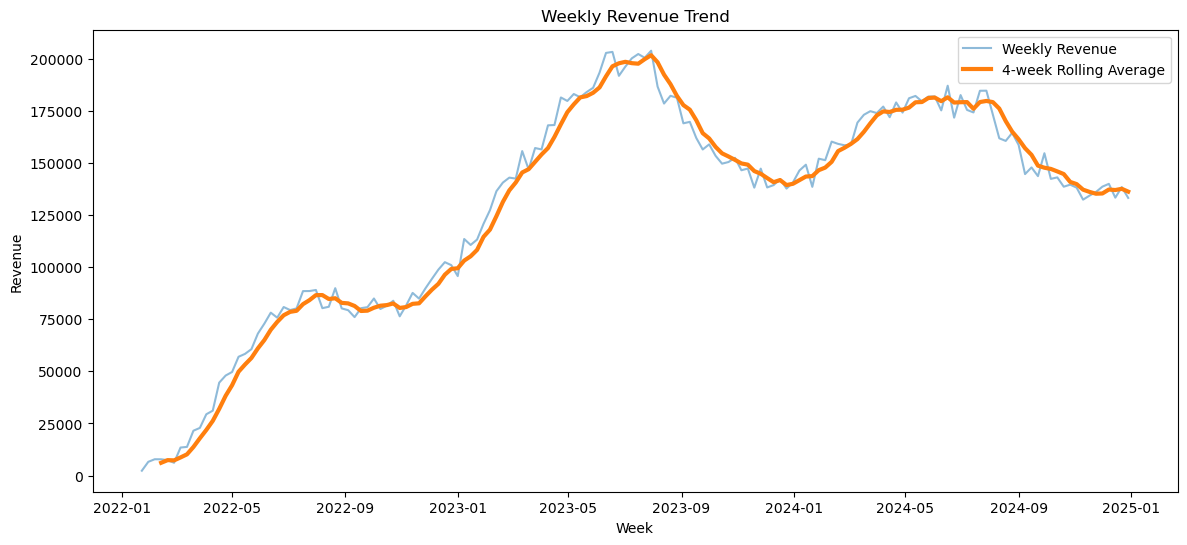

In [50]:
weekly_revenue = df_clean.resample("W", on="date")["revenue"].sum()
weekly_rolling = weekly_revenue.rolling(4).mean()

weekly_revenue = weekly_revenue.iloc[:-1]
weekly_rolling = weekly_rolling.iloc[:-1]

plt.figure(figsize=(14, 6))

plt.plot(weekly_revenue, alpha=0.5, label="Weekly Revenue")
plt.plot(weekly_rolling, linewidth=3, label="4-week Rolling Average")

plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.legend()

plt.show()

**Insight**

Revenue reached its highest level around the middle of 2023

After that, revenue decreased and became more stable during 2024

The graph also shows a seasonal pattern, because sales activity appears to be higher around the middle of the year and lower toward the end of the year

### Promotion Effect Analysis

This section evaluates whether promotional campaigns increase sales

In [48]:
promo_units = df_clean.groupby("promotion_flag")["units_sold"].mean()

no_promo = promo_units.loc[0]
promo = promo_units.loc[1]
growth_percent = (promo - no_promo) / no_promo * 100

display(promo_units.round(2))

promotion_flag
0    17.44
1    34.06
Name: units_sold, dtype: float64

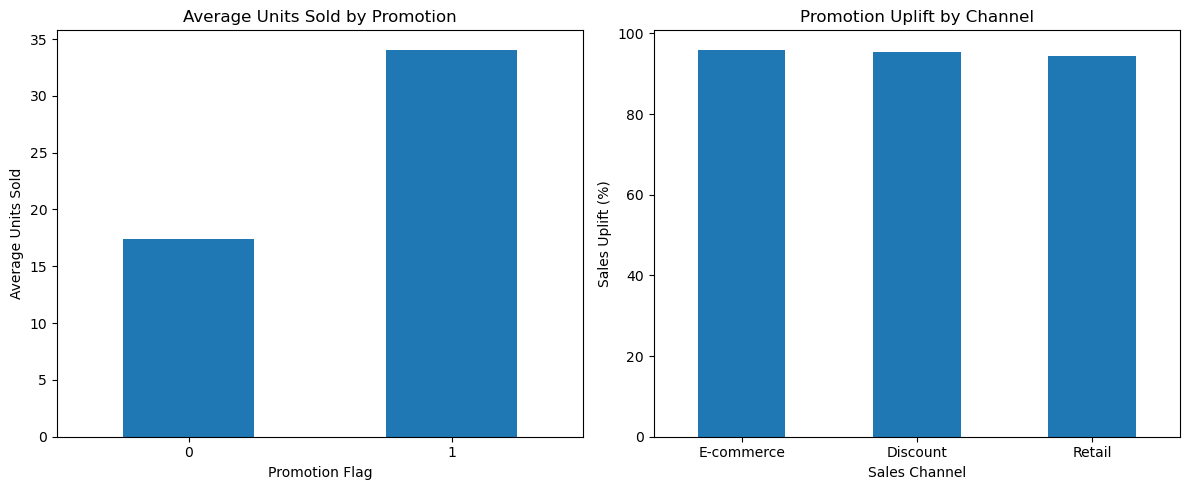


Promotion sales uplift: 95.3%


In [47]:
promo_channel = df_clean.groupby(["channel", "promotion_flag"])["units_sold"].mean().unstack()
promo_channel["uplift_%"] = (promo_channel[1] - promo_channel[0]) / promo_channel[0] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

promo_units.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Units Sold by Promotion")
axes[0].set_xlabel("Promotion Flag")
axes[0].set_ylabel("Average Units Sold")
axes[0].tick_params(axis="x", rotation=0)

promo_channel["uplift_%"].sort_values(ascending=False).plot(kind="bar", ax=axes[1])
axes[1].set_title("Promotion Uplift by Channel")
axes[1].set_xlabel("Sales Channel")
axes[1].set_ylabel("Sales Uplift (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"\nPromotion sales uplift: {growth_percent:.1f}%")

**Insight**

Promotional periods had almost two times higher average unit sales compared to regular periods

The promotion effect is strong across all sales channels, with small differences between retail, e-commerce, and discount

### Inventory & Supply Chain Analysis

This section evaluates inventory turnover, stock shortages, and delivery efficiency

**Inventory turnover metric**

In [58]:
turnover_df = df_clean.loc[df_clean["stock_available"] > 0].copy()

turnover_df["stock_turnover"] = (turnover_df["units_sold"] / turnover_df["stock_available"])

**Turnover by category**

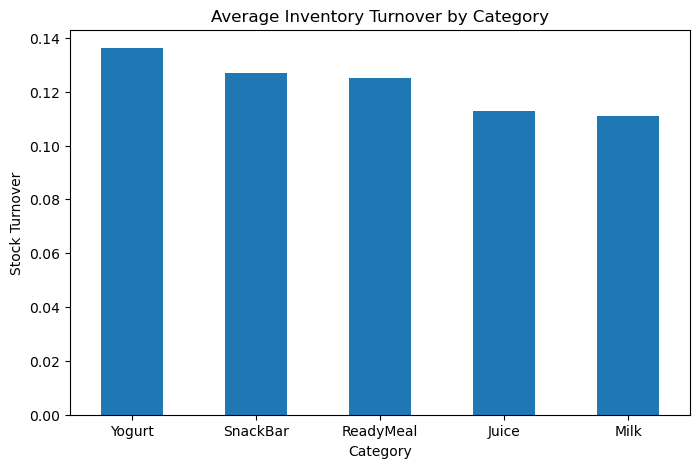

In [59]:
turnover_by_category = (turnover_df.groupby("category")["stock_turnover"].mean().sort_values(ascending=False))

turnover_by_category.plot(kind="bar", figsize=(8,5))

plt.title("Average Inventory Turnover by Category")
plt.xlabel("Category")
plt.ylabel("Stock Turnover")

plt.xticks(rotation=0)

plt.show()

**Insight**

Yogurt products showed the highest inventory turnover, meaning they were sold faster relative to available stock

This also matches the understock analysis, where Yogurt had the largest share of stock shortage cases

Milk and juice categories had lower turnover values, suggesting slower inventory movement and more stable stock levels

**OVERSTOCK / UNDERSTOCK DETECTION**

In [60]:
high_stock = df_clean["stock_available"].quantile(0.75)
low_stock = df_clean["stock_available"].quantile(0.25)

high_sales = df_clean["units_sold"].quantile(0.75)
low_sales = df_clean["units_sold"].quantile(0.25)

overstock = df_clean.loc[(df_clean["stock_available"] > high_stock) & (df_clean["units_sold"] < low_sales)]
understock = df_clean.loc[(df_clean["stock_available"] < low_stock) & (df_clean["units_sold"] > high_sales)]

In [65]:
overstock_percent = (len(overstock) / len(df_clean)) * 100
understock_percent = (len(understock) / len(df_clean)) * 100

understock_categories = (understock["category"].value_counts(normalize=True) * 100)

understock_summary = pd.DataFrame({"share_%": understock_categories.round(2)})

understock_delivery_avg = (understock["delivery_days"].mean())
overall_delivery_avg = (df_clean["delivery_days"].mean())

print(f"Overstock cases: {overstock_percent:.2f}%")
print(f"Understock cases: {understock_percent:.2f}%")
print(f"Average delivery time (understock cases): "f"{understock_delivery_avg:.2f} days")
print(f"Overall average delivery time: "f"{overall_delivery_avg:.2f} days")

display(understock_summary)

Overstock cases: 0.39%
Understock cases: 1.04%
Average delivery time (understock cases): 3.03 days
Overall average delivery time: 3.00 days


,share_%
category,
Yogurt,51.57
ReadyMeal,16.31
SnackBar,15.20
Milk,14.80
Juice,2.12


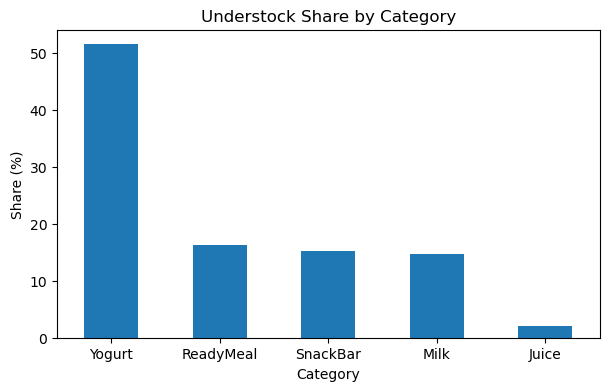

In [71]:
understock_categories.plot(kind="bar", figsize=(7,4))

plt.title("Understock Share by Category")
plt.xlabel("Category")
plt.ylabel("Share (%)")
plt.xticks(rotation=0)

plt.show()

**Insight**

The dataset contains relatively few overstock and understock cases, which suggests generally stable inventory levels

However, yogurt products account for more than half of all understock situations

Combined with the highest inventory turnover rate, this indicates that yogurt products experience stronger demand and faster stock movement compared to other categories

The average delivery time for understock cases is almost identical to the overall dataset average, suggesting that delivery delays do not appear to be the main driver of stock shortages

# Overall Conclusion

The dataset shows relatively stable sales and inventory behavior across regions, channels, and product categories

The analysis identified clear sales trends and seasonal patterns, with stronger sales activity during mid-year periods

Promotions were associated with significantly higher sales across all sales channels

Inventory analysis showed that most categories maintained stable stock levels, although yogurt products experienced faster inventory turnover and a higher share of understock situations, suggesting stronger customer demand

Delivery times were generally stable and did not appear to be strongly related to stock shortages in this dataset

Since the dataset is simulated, some trends and relationships may appear cleaner and more consistent than in real-world business environments, where sales behavior is usually influenced by additional external factors such as holidays, competition, pricing changes, and market disruptions